In [8]:
import keras
from keras import layers
from keras.models import Model
import numpy as np
from keras.datasets import mnist

# 1. Load the dataset
(x_train, _), (x_test, _) = mnist.load_data()

# 2. Make Normalization
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# 3. Reshape the data into 784 bit (CRITICAL for MLP)
# MLP cannot take 2D square images; we must flatten them into 1D vectors
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

# Add noise to the flattened images
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

print(f"x_train_noisy shape: {x_train_noisy.shape}")
print(f"x_test_noisy shape: {x_test_noisy.shape}")

# 4. Build the Denoising Autoencoder model with MLP (Dense) architecture
# Define the input placeholder shape (784 flattened features)
input_img = keras.Input(shape=(784,))

# Encoder: Gradually compresses the 784 features using standard Dense layers
x = layers.Dense(128, activation='relu')(input_img)
x = layers.Dense(64, activation='relu')(x)
encoded = layers.Dense(32, activation='relu')(x) # The Bottleneck (32-dimensional code)

# Decoder: Reconstructs the 784 features back from the 32-dimensional bottleneck
x = layers.Dense(64, activation='relu')(encoded)
x = layers.Dense(128, activation='relu')(x)
# Output layer with 784 nodes and sigmoid activation to reconstruct original pixel values
decoded = layers.Dense(784, activation='sigmoid')(x)

# The full MLP Denoising Autoencoder model
autoencoder = Model(input_img, decoded)

# Separate Encoder model
encoder = Model(input_img, encoded)

# Build the separate Decoder model structure for MLP
encoded_input = keras.Input(shape=(32,))
x_decoder = layers.Dense(64, activation='relu')(encoded_input)
x_decoder = layers.Dense(128, activation='relu')(x_decoder)
decoder_output = layers.Dense(784, activation='sigmoid')(x_decoder)
decoder = Model(encoded_input, decoder_output)


# Compile our autoencoder
autoencoder.compile(optimizer='adam',
                    loss='binary_crossentropy',
                    metrics=['binary_accuracy'])

# 5. Train the model
# Passing flattened noisy images as input and flattened clean images as target
history = autoencoder.fit(x_train_noisy, x_train,
                          epochs=20,
                          batch_size=256,
                          shuffle=True,
                          validation_data=(x_test_noisy, x_test))

# Print evaluation
loss, accuracy = autoencoder.evaluate(x_test_noisy, x_test, verbose=0)

print("\n" + "="*40)
print(f"Test Reconstruction Loss (BCE): {loss:.4f}")
print(f"Test Reconstruction Accuracy:   {accuracy * 100:.2f}%")
print("="*40 + "\n")

# Generate predictions
encoded_imgs = encoder.predict(x_test_noisy)
decoded_imgs = decoder.predict(encoded_imgs)

x_train_noisy shape: (60000, 784)
x_test_noisy shape: (10000, 784)
Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - binary_accuracy: 0.7865 - loss: 0.2583 - val_binary_accuracy: 0.7964 - val_loss: 0.1974
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.8002 - loss: 0.1815 - val_binary_accuracy: 0.8014 - val_loss: 0.1679
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.8034 - loss: 0.1629 - val_binary_accuracy: 0.8031 - val_loss: 0.1569
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.8050 - loss: 0.1540 - val_binary_accuracy: 0.8051 - val_loss: 0.1493
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.8063 - loss: 0.1472 - val_binary_accuracy: 0.8052 - val_loss: 0.1434
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.8071 - loss: 0.1424 - val_binary_accuracy: 0.8058 - val_loss: 0.1402
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - binary_accuracy: 0.8076 - 

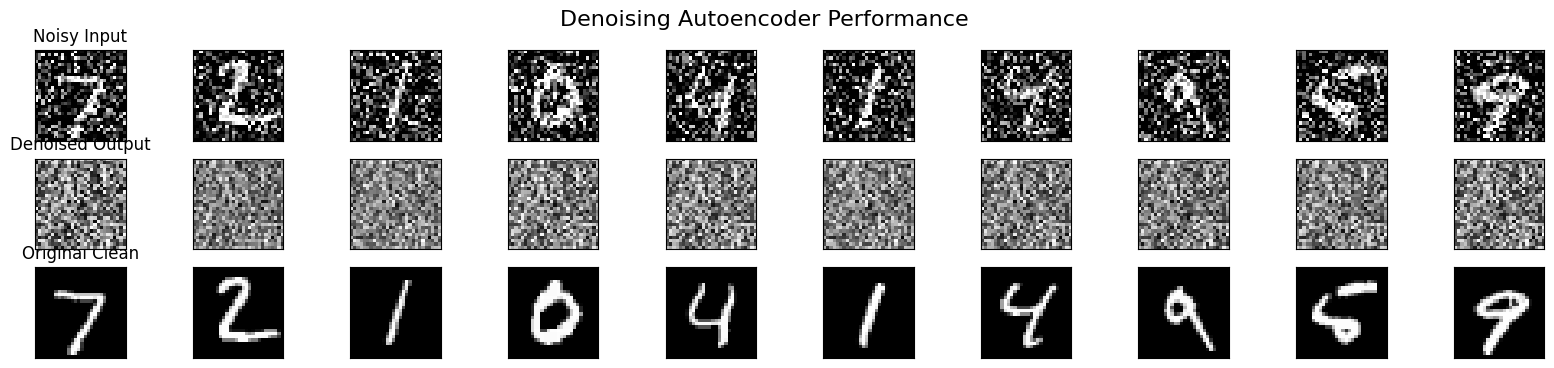

In [9]:
import matplotlib.pyplot as plt

n = 10  # How many digits we will display
plt.figure(figsize=(20, 4))
for i in range(n):


    # Display original clean
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("Original Clean")

    # Display original noisy
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("Noisy Input")

    # Display reconstruction
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("Denoised Output")


plt.suptitle('Denoising Autoencoder Performance', fontsize=16)
plt.show()